In [4]:
# Physics background
# ------------------
#  Gaps in quantum wires with spin-orbit coupling and Zeeman splititng,
#  as theoretically predicted in
#   https://doi.org/10.1103/PhysRevLett.90.256601
#  and (supposedly) experimentally oberved in
#   https://doi.org/10.1038/nphys1626
#
# Kwant features highlighted
# --------------------------
#  - Numpy matrices as values in Builder
import kwant
from matplotlib import pyplot
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg')
# For matrix support
import tinyarray

In [5]:
# define Pauli-matrices for convenience
sigma_0 = tinyarray.array([[1, 0], [0, 1]])
sigma_x = tinyarray.array([[0, 1], [1, 0]])
sigma_y = tinyarray.array([[0, -1j], [1j, 0]])
sigma_z = tinyarray.array([[1, 0], [0, -1]])
t = 1.0
alpha = 1.0
e_z = 0.08
W, L = 10, 30

In [7]:
lat = kwant.lattice.square(norbs=2)
syst = kwant.Builder()
#### Define the scattering region. ####
syst[(lat(x, y) for x in range(L) for y in range(W))] = \
    4 * t * sigma_0 + e_z * sigma_z
# hoppings in x-direction
syst[kwant.builder.HoppingKind((1, 0), lat, lat)] = \
    -t * sigma_0 + 1j * alpha * sigma_y / 2
# hoppings in y-directions
syst[kwant.builder.HoppingKind((0, 1), lat, lat)] = \
    -t * sigma_0 - 1j * alpha * sigma_x / 2

In [8]:
#### Define the left lead. ####
lead = kwant.Builder(kwant.TranslationalSymmetry((-1, 0)))
lead[(lat(0, j) for j in range(W))] = 4 * t * sigma_0 + e_z * sigma_z
# hoppings in x-direction
lead[kwant.builder.HoppingKind((1, 0), lat, lat)] = \
    -t * sigma_0 + 1j * alpha * sigma_y / 2
# hoppings in y-directions
lead[kwant.builder.HoppingKind((0, 1), lat, lat)] = \
    -t * sigma_0 - 1j * alpha * sigma_x / 2
#### Attach the leads and finalize the system. ####
syst.attach_lead(lead)
syst.attach_lead(lead.reversed())
syst = syst.finalized()

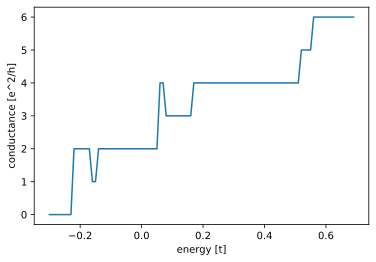

In [9]:
# Compute conductance
energies=[0.01 * i - 0.3 for i in range(100)]
data = []
for energy in energies:
    smatrix = kwant.smatrix(syst, energy)
    data.append(smatrix.transmission(1, 0))

pyplot.figure()
pyplot.plot(energies, data)
pyplot.xlabel("energy [t]")
pyplot.ylabel("conductance [e^2/h]")
pyplot.show()